STEP - 1

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from glob import glob
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2, EfficientNetB0


C:\Users\JAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/attr_value.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\JAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/tensor.proto. Please update the gencode to avoid compatibility violations in the next runtime release.
  warnings.warn(
C:\Users\JAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\google\protobuf\runtime_version.py:98: UserWarning: Protobuf gencode version 5.28.3 is exactly one major version older than the runtime version 6.31.1 at tensorflow/core/framework/res

In [2]:
# Paths
train_dir = r"C:\Users\JAI\Downloads\archive\Garbage classification\Garbage classification\data\train"
val_dir = r"C:\Users\JAI\Downloads\archive\Garbage classification\Garbage classification\data\val\test" 

img_height, img_width = 224, 224
batch_size = 32
num_classes = 6

STEP - 2

Convert all images to RGB (to avoid stem_conv errors)

In [3]:
def convert_to_rgb(folder):
    for cls in os.listdir(folder):
        cls_path = os.path.join(folder, cls)
        if not os.path.isdir(cls_path):
            continue
        for img_name in os.listdir(cls_path):
            img_path = os.path.join(cls_path, img_name)
            try:
                img = Image.open(img_path).convert('RGB')
                img.save(img_path)
            except:
                print(f"Skipped: {img_path}")

# Convert train & val/test
convert_to_rgb(train_dir)
convert_to_rgb(val_dir)


STEP - 3

Exploratory Data Analysis (EDA)

C:\Users\JAI\AppData\Local\Temp\ipykernel_6784\2476888727.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="viridis")


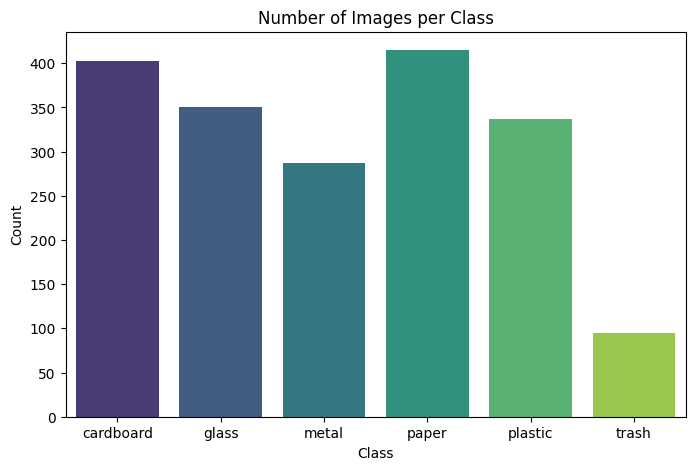

In [4]:
classes = sorted(os.listdir(train_dir))
# Number of images per class
image_counts = {cls: len(os.listdir(os.path.join(train_dir, cls))) for cls in classes}

plt.figure(figsize=(8,5))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()), palette="viridis")
plt.title("Number of Images per Class")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

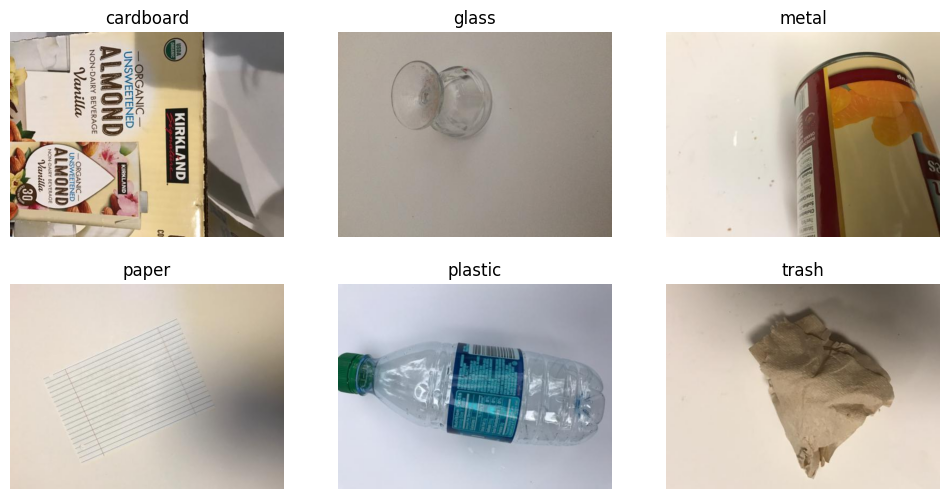

In [5]:

# Show sample images per class
plt.figure(figsize=(12,6))
for i, cls in enumerate(classes):
    img_path = random.choice(glob(os.path.join(train_dir, cls, '*')))
    img = Image.open(img_path)
    plt.subplot(2, 3, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis('off')
plt.show()


STEP - 4

Data Augmentation & Generators

In [6]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.1,
    height_shift_range=0.1
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=True
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(img_height, img_width),
    batch_size=batch_size,
    class_mode='categorical',
    color_mode='rgb',
    shuffle=False
)


Found 1887 images belonging to 6 classes.
Found 383 images belonging to 6 classes.


STEP - 5

Build Transfer Learning Models

In [7]:
def build_transfer_model(base_model, num_classes=num_classes):
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    x = Dense(128, activation='relu')(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=predictions)
    return model


STEP -6

Model 1: MobileNetV2 (Pretrained)

In [8]:
mobilenet_base = MobileNetV2(input_shape=(img_height,img_width,3), include_top=False, weights='imagenet')
mobilenet_model = build_transfer_model(mobilenet_base)
mobilenet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_mobilenet = mobilenet_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


C:\Users\JAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.5633 - loss: 1.1567 - val_accuracy: 0.7128 - val_loss: 0.7566
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7255 - loss: 0.7319 - val_accuracy: 0.7520 - val_loss: 0.6753
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.7737 - loss: 0.6121 - val_accuracy: 0.7493 - val_loss: 0.6466
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.7970 - loss: 0.5633 - val_accuracy: 0.7755 - val_loss: 0.6715
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.8129 - loss: 0.5253 - val_accuracy: 0.7702 - val_loss: 0.6020
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8193 - loss: 0.4816 - val_accuracy: 0.7990 - val_loss: 0.5828
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8198 - loss: 0.4737 - val_accuracy: 0.7807 - val_loss: 0.5812
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 61s 1s/step - accuracy: 0.8304 - loss: 0.4438 - val_accuracy: 0.8068 - val_loss

Model 2: EfficientNetB0 (Train from scratch)

In [9]:
efficient_base = EfficientNetB0(input_shape=(img_height,img_width,3), include_top=False, weights=None)
efficient_model = build_transfer_model(efficient_base)
efficient_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_efficient = efficient_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.2077 - loss: 1.7713 - val_accuracy: 0.2350 - val_loss: 1.7548
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 123s 2s/step - accuracy: 0.2289 - loss: 1.7347 - val_accuracy: 0.2350 - val_loss: 1.7361
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 120s 2s/step - accuracy: 0.2130 - loss: 1.7247 - val_accuracy: 0.2350 - val_loss: 1.7334
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 117s 2s/step - accuracy: 0.2136 - loss: 1.7216 - val_accuracy: 0.2350 - val_loss: 1.7332
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.2157 - loss: 1.7230 - val_accuracy: 0.2350 - val_loss: 1.7338
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.2130 - loss: 1.7215 - val_accuracy: 0.2350 - val_loss: 1.7332
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - accuracy: 0.2305 - loss: 1.7231 - val_accuracy: 0.2350 - val_loss: 1.7331
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.2205 - loss: 1.7233 - val_accuracy: 0.2350 - v

Model 3: Baseline CNN

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten

cnn_model = Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(img_height,img_width,3)),
    MaxPooling2D(2,2),
    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128,activation='relu'),
    Dense(num_classes,activation='softmax')
])
cnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

history_cnn = cnn_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10
)


C:\Users\JAI\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.3710 - loss: 2.1520 - val_accuracy: 0.4360 - val_loss: 1.5007
Epoch 2/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5077 - loss: 1.2551 - val_accuracy: 0.5013 - val_loss: 1.2630
Epoch 3/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - accuracy: 0.5601 - loss: 1.1547 - val_accuracy: 0.5196 - val_loss: 1.2851
Epoch 4/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 90s 2s/step - accuracy: 0.5893 - loss: 1.0660 - val_accuracy: 0.5744 - val_loss: 1.1454
Epoch 5/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 92s 2s/step - accuracy: 0.6253 - loss: 0.9945 - val_accuracy: 0.5640 - val_loss: 1.1996
Epoch 6/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 95s 2s/step - accuracy: 0.6524 - loss: 0.9420 - val_accuracy: 0.5614 - val_loss: 1.1276
Epoch 7/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 106s 2s/step - accuracy: 0.6497 - loss: 0.9332 - val_accuracy: 0.5901 - val_loss: 1.1436
Epoch 8/10
59/59 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6751 - loss: 0.8841 - val_accuracy: 0.6554 - val_loss

Compare Model Accuracies

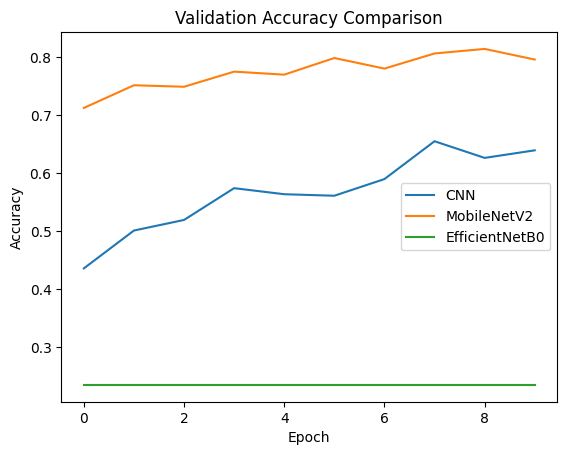

In [12]:
models = ['CNN','MobileNetV2','EfficientNetB0']
histories = [history_cnn, history_mobilenet, history_efficient]

for name, h in zip(models,histories):
    plt.plot(h.history['val_accuracy'], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


Save Models 

In [11]:
# Save CNN model
cnn_model.save("cnn_model.h5")

# Save MobileNetV2 model
mobilenet_model.save("mobilenet_model.h5")

# Save EfficientNetB0 model
efficient_model.save("efficientnet_model.h5")


Determine the Best Model (based on val_accuracy)

In [13]:
# Get final validation accuracies
val_acc_cnn = history_cnn.history['val_accuracy'][-1]
val_acc_mobilenet = history_mobilenet.history['val_accuracy'][-1]
val_acc_efficient = history_efficient.history['val_accuracy'][-1]

# Compare
val_accs = [val_acc_cnn, val_acc_mobilenet, val_acc_efficient]
model_names = ['cnn_model.h5', 'mobilenet_model.h5', 'efficientnet_model.h5']

best_model_idx = np.argmax(val_accs)
best_model_name = model_names[best_model_idx]

print(f"Best model: {best_model_name} with val_accuracy = {val_accs[best_model_idx]:.4f}")


Best model: mobilenet_model.h5 with val_accuracy = 0.7963


Load the Best Model for Streamlit

In [14]:
from tensorflow.keras.models import load_model

best_model = load_model(best_model_name)


STEP - 7

STREAMLIT APP 

In [ ]:
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import os


# 1. Load Best Model

# Replace with the name of your saved best model
BEST_MODEL_PATH = r"C:\Users\JAI\Downloads\archive\Garbage classification\Garbage classification\mobilenet_model.h5"
model = load_model(BEST_MODEL_PATH)

# Load class indices from training generator
# Make sure you saved it before or recreate
CLASS_INDICES = {
    0: 'cardboard',
    1: 'glass',
    2: 'metal',
    3: 'paper',
    4: 'plastic',
    5: 'trash'
}


# 2. Streamlit UI


st.set_page_config(page_title="RecycleVision", layout="centered")
st.title("♻️ RecycleVision - Garbage Image Classification")
st.write("Upload an image of garbage and the model will predict its category.")

# Upload image
uploaded_file = st.file_uploader("Choose an image...", type=["jpg","jpeg","png"])

if uploaded_file is not None:
    # Display uploaded image
    img = Image.open(uploaded_file).convert('RGB')
    st.image(img, caption="Uploaded Image", use_column_width=True)

    
    # 3. Preprocess & Predict
    
    def predict(img, model, target_size=(224,224)):
        img_resized = img.resize(target_size)
        img_array = np.array(img_resized)/255.0
        img_array = np.expand_dims(img_array, axis=0)
        preds = model.predict(img_array)
        top_idx = np.argmax(preds)
        confidence = preds[0][top_idx]
        return CLASS_INDICES[top_idx], confidence, preds[0]

    label, conf, all_preds = predict(img, model)

    # Display results
    st.write(f"**Predicted Class:** {label}")
    st.write(f"**Confidence:** {conf*100:.2f}%")

    # Optional: Show top 3 predictions
    top3_idx = np.argsort(all_preds)[-3:][::-1]
    st.write("**Top-3 Predictions:**")
    for idx in top3_idx:
        st.write(f"{CLASS_INDICES[idx]}: {all_preds[idx]*100:.2f}%")
